# 06 — Radar Chart: Semua Metrik per Metode (Top-5)

**Pertanyaan yang dijawab:** Bagaimana profil keseluruhan tiap metode jika dilihat dari 5 metrik sekaligus?

**Cara baca:** Semakin luas area polygon = semakin baik performa secara keseluruhan. Bentuk polygon menunjukkan profil kekuatan/kelemahan tiap metode.

> Cocok untuk **ringkasan di bagian kesimpulan** laporan — satu gambar merangkum seluruh komparasi.

> **Prasyarat:** Jalankan `00_load_data.ipynb` terlebih dahulu.

## 1. Import & Load Cache

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PKL_DIR = Path("_cache")

with open(PKL_DIR / "data_eval.pkl", "rb") as f:
    cache = pickle.load(f)

top5    = cache["top5"]
FIG_DIR = cache["FIG_DIR"]

METHOD_ORDER  = ["Element-Based", "MaxMin Semantic", "Recursive"]
METHOD_COLORS = {
    "Element-Based":   "#2196F3",
    "MaxMin Semantic": "#FF9800",
    "Recursive":       "#4CAF50",
}

plt.rcParams.update({"font.family": "sans-serif", "font.size": 11})
print(f"Top-5 rows: {top5.shape[0]}")

Top-5 rows: 90


## 2. Hitung Rata-rata Semua Metrik

In [2]:
METRIC_COLS  = ["precision_at_k", "recall_at_k", "mrr", "bleu", "rouge_l_recall"]
METRIC_LABELS = ["Precision@5", "Recall@5", "MRR", "BLEU", "ROUGE-L"]

metrics_avg = (
    top5
    .groupby("method")[METRIC_COLS]
    .mean()
    .reindex(METHOD_ORDER)
    .round(4)
)
metrics_avg.columns = METRIC_LABELS
print("Rata-rata metrik per metode (Top-5):")
display(metrics_avg)

Rata-rata metrik per metode (Top-5):


,Precision@5,Recall@5,MRR,BLEU,ROUGE-L
method,,,,,
Element-Based,0.1286,0.3923,0.3542,0.1178,0.7005
MaxMin Semantic,0.1310,0.4466,0.3488,0.1052,0.6369
Recursive,0.1448,0.3523,0.4293,0.1440,0.6838


## 3. Plot Radar Chart

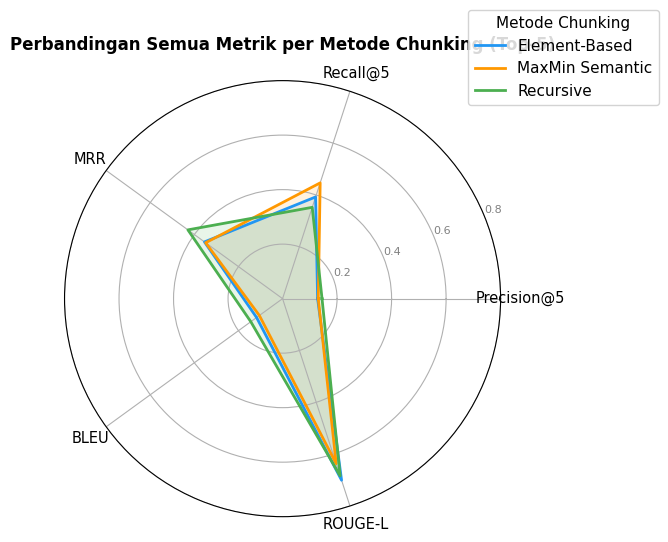

In [3]:
N      = len(METRIC_LABELS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # tutup polygon

fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw=dict(polar=True))

for method in METHOD_ORDER:
    values = metrics_avg.loc[method].tolist()
    values += values[:1]
    ax.plot(angles, values,
            color=METHOD_COLORS[method], linewidth=2, label=method)
    ax.fill(angles, values,
            color=METHOD_COLORS[method], alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(METRIC_LABELS, fontsize=10.5)
ax.set_ylim(0, 0.8)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], fontsize=8, color="gray")
ax.set_title(
    "Perbandingan Semua Metrik per Metode Chunking (Top-5)",
    fontsize=12, fontweight="bold", pad=22,
)
ax.legend(
    title="Metode Chunking",
    loc="upper right",
    bbox_to_anchor=(1.38, 1.18),
    framealpha=0.85,
)

fig.tight_layout()
plt.show()

## 4. Simpan PNG

In [4]:
out_path = FIG_DIR / "06_radar_all_metrics.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Tersimpan: {out_path.resolve()}")

Tersimpan: D:\My Files\Kuliah\SKRIPSI\rag-skripsi\results\final\figures\06_radar_all_metrics.png


## 5. Interpretasi

- **Recursive** punya area polygon paling luas — unggul di Precision@5, MRR, dan BLEU.
- **MaxMin Semantic** unggul di Recall@5 — lebih banyak chunk relevan yang ditemukan, tapi ranking-nya tidak selalu tepat.
- **Element-Based** berada di tengah — performa yang seimbang di semua metrik.
- Ketiga metode memiliki profil ROUGE-L yang hampir sama — kualitas teks jawaban relatif setara.
- Tidak ada satu metode yang dominan di semua dimensi, sehingga pilihan optimal bergantung pada prioritas: ranking (MRR → Recursive) atau coverage (Recall → MaxMin).